In [49]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
# Load dataset

df = pd.read_csv("HousingData.csv")

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [51]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Check data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (506, 14)

Columns:

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Data Types:

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


In [52]:
# Check null values

print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [53]:
# Statistical summary

df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [54]:
# Check missing values

print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [55]:
# Remove rows containing NaN values

df = df.dropna()

In [56]:
# Check again

print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


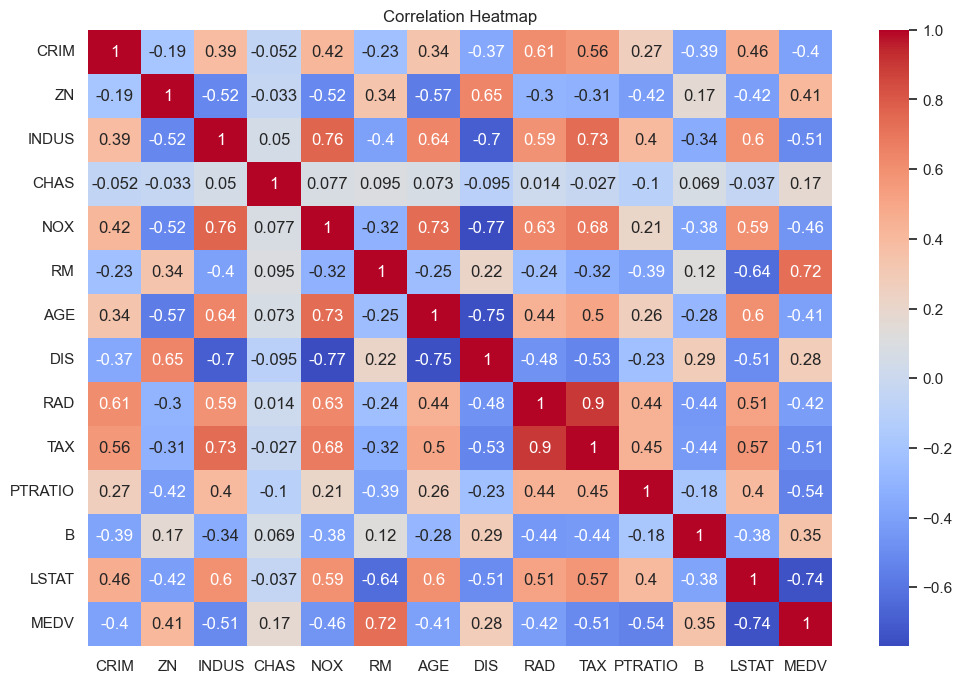

In [61]:
# Correlation matrix

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [58]:
# Independent variables

X = df.drop('MEDV', axis=1)

# Dependent variable

y = df['MEDV']

In [59]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (315, 13)
Testing Data Shape: (79, 13)


In [60]:
from sklearn.linear_model import LinearRegression

# Create model

model = LinearRegression()

# Train model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [62]:
# Predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[29.22850199 17.5037472  21.80803847 30.4942528  18.50265527 34.7432311
 22.07369779 30.7541295  33.52029866 14.82910783]


In [63]:
# Create comparison DataFrame

comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
93,25.0,29.228502
352,18.6,17.503747
319,21.0,21.808038
65,23.5,30.494253
499,17.5,18.502655
260,33.8,34.743231
50,19.7,22.073698
300,24.8,30.754129
187,32.0,33.520299
140,14.0,14.829108


In [64]:
# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error

rmse = np.sqrt(mse)

# R2 Score

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 31.45404766495098
Root Mean Squared Error: 5.608390826694497
R2 Score: 0.6270849941673178


In [66]:
print("""
Inference:

1. Linear Regression was used to predict house prices.

2. Features like RM (number of rooms) positively affect house prices.

3. Features like LSTAT (lower status population percentage)
   negatively affect house prices.

4. The R2 Score indicates how well the model fits the data.

5. Lower RMSE means better prediction accuracy.
""")


Inference:

1. Linear Regression was used to predict house prices.

2. Features like RM (number of rooms) positively affect house prices.

3. Features like LSTAT (lower status population percentage)
   negatively affect house prices.

4. The R2 Score indicates how well the model fits the data.

5. Lower RMSE means better prediction accuracy.

